# From Perceptron to Deep Learning

## Project: Student Exam Success Predictor

**A hands-on journey through Artificial Neural Networks(ANN)**
In this notebook we build a real, relatable machine-learning project - predicting whether a sutdent will **pass or fail** an exam based on their habits(study hours, sleep attendace, previous scores, etc.) - and use it to learn every core Deep learning concept

| **#** | **Concept** | **Where we cover it** |
| --- | --- | --- |
| 1 | Perceptron | Part 1 |
| 2 | Activation Functions | Part 2 |
| 3 | Architecture: Layers, Weights, Biases  | Part 3 |
| 4 | Forward & Backpropagation | Part 4 |
| 5 | Optimization: Gradient Descent & Adam | Part 5 |
| 6 | The Capstone Project(Keras) | Part 6 |
| 7 | Overfitting | Part 7 |
| 8 | Regularization: Dropout, BatchNorm, Early Stopping | Part 8 |

Why this project? Every student intuitively understands study more, sleep well, attend class->better result that makes it the perfect project to see how neural networks learn the same relationship from data

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)
plt.rcParams['figure.figsize'] = (8,4)


In [23]:
class Perceptron:
    def __init__(self, n_features, lr = 0.1, epochs = 20):
        self.w = np.zeros(n_features)
        self.b = 0.0
        self.lr = lr
        self.epochs = epochs
    
    def step(self, z):
        return np.where(z >= 0, 1, 0)
    
    def predict(self, X):
        return self.step(X @ self.w + self.b)
    
    def fit(self, X, y):
        for epoch in range(self.epochs):
            errors = 0
            for xi, target in zip(X, y):
                update = self.lr * (target - self.step(xi @ self.w + self.b))
                self.w += update * xi
                self.b += update
                errors += int(update != 0.0)
            if errors == 0:
                print(f'Converged at epoch {epoch}')
                break
        return self

xToy = np.array([[0,0], [0,1], [1,0], [1,1]])
yToy = np.array([0,0,0,1])

p = Perceptron(n_features=2).fit(xToy, yToy)
print('Learned weights:', p.w, 'bias', round(p.b, 3))
print('Predictions:', p.predict(xToy), '| Truth:', yToy)


Converged at epoch 3
Learned weights: [0.2 0.1] bias -0.2
Predictions: [0 0 0 1] | Truth: [0 0 0 1]


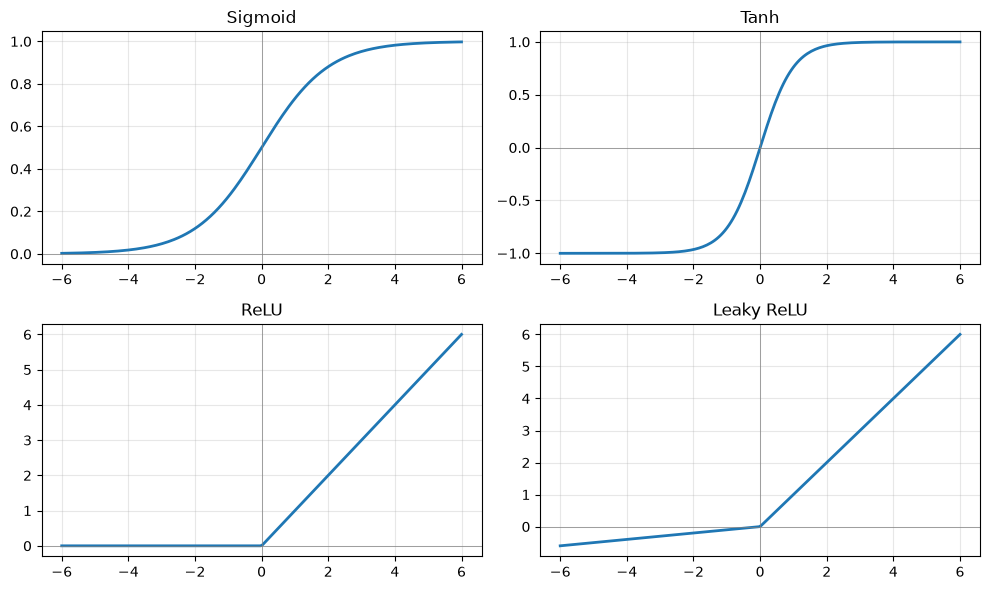

In [24]:
def sigmoid(z):     return 1 / (1 + np.exp(-z))
def tanh(z):        return np.tanh(z)
def relu(z):        return np.maximum(0, z)
def leaky_relu(z): return np.where(z > 0, z, 0.1 * z)

z = np.linspace(-6, 6, 200)
funcs = {'Sigmoid': sigmoid, 'Tanh': tanh, 'ReLU': relu, 'Leaky ReLU': leaky_relu}

fig, axes = plt.subplots(2,2,figsize=(10,6))
for ax, (name, f) in zip(axes.ravel(), funcs.items()):
    ax.plot(z, f(z), lw = 2)
    ax.axhline(0, color = 'gray', lw = 0.5)
    ax.axvline(0, color = 'gray', lw = 0.5)
    ax.set_title(name)
    ax.grid(alpha = 0.3)
plt.tight_layout()
plt.show()

In [25]:
def softmax(z):
    e = np.exp(z - np.max(z))
    return e / e.sum()

scores = np.array([2.0, 1.0, 0.1])
print('Raw Scores : ', scores)
print('Softmax    : ', np.round(softmax(scores), 3), '(sums to ', round(softmax(scores).sum(), 3), ')')

Raw Scores :  [2.  1.  0.1]
Softmax    :  [0.659 0.242 0.099] (sums to  1.0 )


In [26]:
layers = [4,5,1]
total = 0

for i in range(len(layers) - 1):
    n_in, n_out = layers[i], layers[i+1]
    w_count = n_in * n_out
    b_count = n_out
    total += w_count + b_count
    print(f'Layer {i} -> {i+1}: weights = {w_count:2d} biases = {b_count:2d}')
print(f'Total trainable parameters: {total}')

Layer 0 -> 1: weights = 20 biases =  5
Layer 1 -> 2: weights =  5 biases =  1
Total trainable parameters: 31


# Part 4 - Forward & Backpropogation

this is the heart of learning. Two passes per training step:
1. **Forward pass:** push inputs thruogh the layers to get a prediciton
2. **Backward pass(backpropogation):** measure the erroe(loss), then use the chain rule to compute how much each weight contributed to that error (the gradient), and nudge weights to reduce it.

To make it crystal clear, we build a 2 layer neural network from scratch in pure NumPy 

In [27]:
x = np.array([[0,0], [0,1], [1,0], [1,1]], dtype = float)
y = np.array([[0], [1], [1], [0]], dtype = float)

def sig(z): return 1 / (1 + np.exp(-z))
def dsig(a): return a * (1 - a)

n_in, n_hidden, n_out = 2, 4, 1
W1 = np.random.randn(n_in, n_hidden) * 0.5
b1 = np.zeros((1, n_hidden))
W2 = np.random.randn(n_hidden, n_out) * 0.5
b2 = np.zeros((1, n_out))

lr = 0.5
losses = []
for epoch in range(5000):
    z1 = x @ W1 + b1
    a1 = sig(z1)
    z2 = a1 @ W2 + b2
    a2 = sig(z2)

    loss = np.mean((a2 - y) ** 2)
    losses.append(loss)

    d_a2 = 2 * (a2 - y) / len(y)
    d_z2 = d_a2 * dsig(a2)
    d_W2 = a1.T @ d_z2
    d_b2 = d_z2.sum(axis = 0, keepdims = True)

    d_a1 = d_z2 @ W2.T
    d_z1 = d_a1 * dsig(a1)
    d_W1 = x.T @ d_z1
    d_b1 = d_z1.sum(axis = 0, keepdims = True)
    
    W2 -= lr * d_W2
    b2 -= lr * d_b2
    W1 -= lr * d_W1
    b1 -= lr * d_b1

print('Final loss:', round(losses[-1], 5))
print('Predictions:', np.round(a2.ravel(), 2), '| Truth:', y.ravel())

Final loss: 0.00266
Predictions: [0.06 0.95 0.95 0.05] | Truth: [0. 1. 1. 0.]


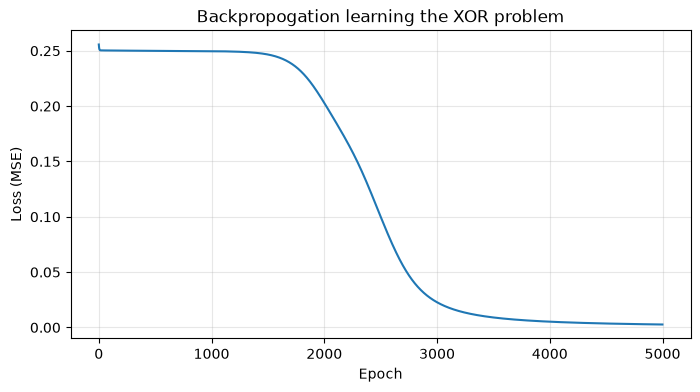

In [32]:
plt.plot(losses)
plt.title('Backpropogation learning the XOR problem')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.grid(alpha = 0.3)
plt.show()